### NATURAL LANGUAGE PROCESSING LAB
### Experiment 6: N-gram Language Model Training, Testing and Evaluation using NLTK Library

---

### 1. Aim of the Experiment
To benchmark next-token prediction behavior and model limits under strict context constraints ($N=2$ Bigram vs $N=3$ Trigram) using explicit NLTK frequency tables and `nltk.lm` modules, and to evaluate model perplexity.

### Step 1: Preprocess Data and Build Frequency Tables
- Download tokenizer dependencies (`punkt`, `punkt_tab`).
- Tokenize the input sequence.

In [6]:
import nltk
from nltk.lm.preprocessing import padded_everygram_pipeline, pad_both_ends
from nltk.lm import MLE, Laplace
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
import pandas as pd
import matplotlib.pyplot as plt

# Ensure tokenization resources are downloaded
nltk.download('punkt')
nltk.download('punkt_tab')

# 1. Prepare raw training data (equivalent to the infini-gram string)
train_text = ["the cat sat on the mat and then cat ran away quickly. the dog barked at the cat."]

# Tokenize into a list of word lists (sentences)
tokenized_train = [word_tokenize(sent.lower()) for sent in train_text]
print("Tokenized Training Data:", tokenized_train[0])

Tokenized Training Data: ['the', 'cat', 'sat', 'on', 'the', 'mat', 'and', 'then', 'cat', 'ran', 'away', 'quickly', '.', 'the', 'dog', 'barked', 'at', 'the', 'cat', '.']


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\raval\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\raval\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


### Step 2: Train Bigram ($N=2$) and Trigram ($N=3$) Models
- Use `padded_everygram_pipeline` to extract n-grams and vocabulary.
- Fit Maximum Likelihood Estimation (`MLE`) models.

In [7]:
# 2. Train Bigram Model (N=2)
n_bigram = 2
train_data_2, padded_vocab_2 = padded_everygram_pipeline(n_bigram, tokenized_train)
model_bigram = MLE(n_bigram)
model_bigram.fit(train_data_2, padded_vocab_2)

# 3. Train Trigram Model (N=3)
n_trigram = 3
train_data_3, padded_vocab_3 = padded_everygram_pipeline(n_trigram, tokenized_train)
model_trigram = MLE(n_trigram)
model_trigram.fit(train_data_3, padded_vocab_3)

print("NLTK Bigram and Trigram models trained successfully.")

# Inspect frequency tables
print("\n--- Frequency Tables ---")
print("Bigram context counts for ('cat'):", dict(model_bigram.context_counts(('cat',))))
print("Trigram context counts for ('the', 'cat'):", dict(model_trigram.context_counts(('the', 'cat'))))

NLTK Bigram and Trigram models trained successfully.

--- Frequency Tables ---
Bigram context counts for ('cat'): {'sat': 1, 'ran': 1, '.': 1}
Trigram context counts for ('the', 'cat'): {'sat': 1, '.': 1}


### Step 3: Test Both N-gram Models
- Test Context: `prompt = "the cat"`
- Evaluate next token probability distribution $P(w \mid \text{context})$ for both models.

In [8]:
# Test Context
prompt = "the cat"
tokens = word_tokenize(prompt.lower())

# Bigram context: ('cat',)
ctx_bi = (tokens[-1],)
# Trigram context: ('the', 'cat')
ctx_tri = tuple(tokens[-2:])

candidates = ['sat', 'ran', '.', 'on', 'away']
table = []
for w in candidates:
    p_bi = model_bigram.score(w, ctx_bi)
    p_tri = model_trigram.score(w, ctx_tri)
    table.append({'Candidate': w, "P(w|'cat') [Bigram]": p_bi, "P(w|'the cat') [Trigram]": p_tri})

df_res = pd.DataFrame(table)
print(df_res.to_string(index=False))

print("\nGenerated Bigram sentence:", ' '.join(model_bigram.generate(6, text_seed=['cat'])))
print("Generated Trigram sentence:", ' '.join(model_trigram.generate(6, text_seed=['the', 'cat'])))

Candidate  P(w|'cat') [Bigram]  P(w|'the cat') [Trigram]
      sat             0.333333                       0.5
      ran             0.333333                       0.0
        .             0.333333                       0.5
       on             0.000000                       0.0
     away             0.000000                       0.0

Generated Bigram sentence: ran away quickly . the dog
Generated Trigram sentence: sat on the mat and then


### Step 4: Find Perplexity for Both Models
- Compute Perplexity ($PP$) on test sequences: `"the cat sat"` (seen in both) and `"the cat ran"` (seen in bigram, unseen in trigram).
- Demonstrate MLE zero-frequency limitation and how Laplace smoothing handles it.

In [9]:
# Train Laplace models for comparison
td2, pv2 = padded_everygram_pipeline(2, tokenized_train)
lap_bigram = Laplace(2)
lap_bigram.fit(td2, pv2)

td3, pv3 = padded_everygram_pipeline(3, tokenized_train)
lap_trigram = Laplace(3)
lap_trigram.fit(td3, pv3)

test_phrases = {
    'the cat sat': ['the', 'cat', 'sat'],
    'the cat ran': ['the', 'cat', 'ran']
}

ppl_data = []
for phrase, seq in test_phrases.items():
    bg_ngrams = list(ngrams(seq, 2))
    tg_ngrams = list(ngrams(seq, 3))
    
    ppl_bi_mle = model_bigram.perplexity(bg_ngrams)
    ppl_tri_mle = model_trigram.perplexity(tg_ngrams)
    
    ppl_bi_lap = lap_bigram.perplexity(bg_ngrams)
    ppl_tri_lap = lap_trigram.perplexity(tg_ngrams)
    
    ppl_data.append({
        'Sequence': phrase,
        'Bigram MLE PPL': round(ppl_bi_mle, 4),
        'Trigram MLE PPL': round(ppl_tri_mle, 4) if ppl_tri_mle != float('inf') else 'inf',
        'Bigram Laplace PPL': round(ppl_bi_lap, 4),
        'Trigram Laplace PPL': round(ppl_tri_lap, 4)
    })

df_ppl = pd.DataFrame(ppl_data)
print(df_ppl.to_string(index=False))

   Sequence  Bigram MLE PPL Trigram MLE PPL  Bigram Laplace PPL  Trigram Laplace PPL
the cat sat          2.4495             2.0              8.3666                  9.5
the cat ran          2.4495             inf              8.3666                 19.0


### Step 5: Visualizations & Graphs (Workflow Requirement 2)

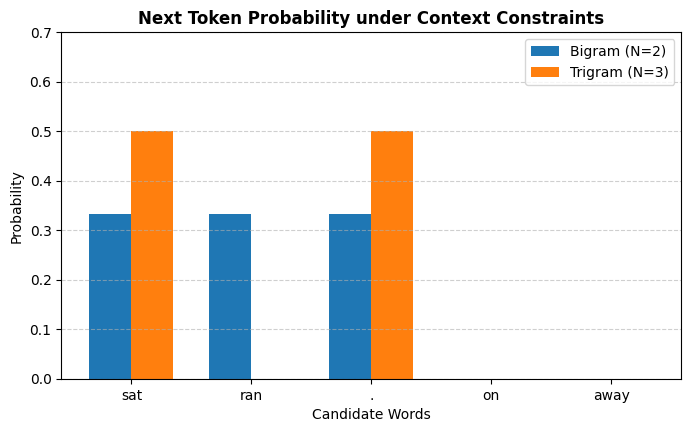

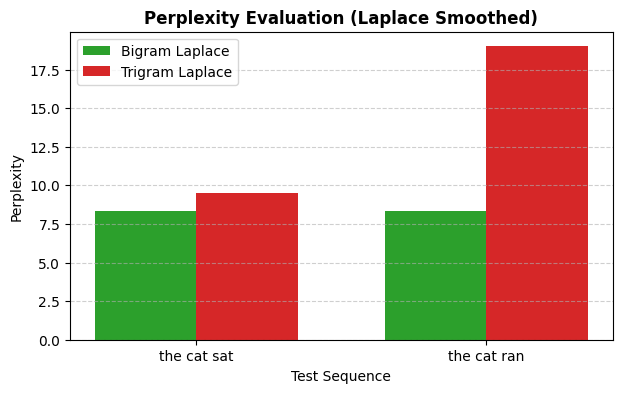

In [10]:
# Plot 1: Next Token Probability Distribution
fig, ax = plt.subplots(figsize=(8, 4.5))
width = 0.35
idx = range(len(candidates))

ax.bar([i - width/2 for i in idx], df_res["P(w|'cat') [Bigram]"], width=width, label="Bigram (N=2)", color='#1f77b4')
ax.bar([i + width/2 for i in idx], df_res["P(w|'the cat') [Trigram]"], width=width, label="Trigram (N=3)", color='#ff7f0e')

ax.set_title("Next Token Probability under Context Constraints", fontweight='bold')
ax.set_xlabel("Candidate Words")
ax.set_ylabel("Probability")
ax.set_xticks(list(idx))
ax.set_xticklabels(candidates)
ax.set_ylim(0, 0.7)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# Plot 2: Perplexity Comparison across Test Sequences
fig, ax = plt.subplots(figsize=(7, 4))
x_labels = list(test_phrases.keys())
idx_ppl = range(len(x_labels))

ax.bar([i - width/2 for i in idx_ppl], df_ppl['Bigram Laplace PPL'], width=width, label='Bigram Laplace', color='#2ca02c')
ax.bar([i + width/2 for i in idx_ppl], df_ppl['Trigram Laplace PPL'], width=width, label='Trigram Laplace', color='#d62728')

ax.set_title("Perplexity Evaluation (Laplace Smoothed)", fontweight='bold')
ax.set_xlabel("Test Sequence")
ax.set_ylabel("Perplexity")
ax.set_xticks(list(idx_ppl))
ax.set_xticklabels(x_labels)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()